In [24]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt



In [25]:
df = pd.read_csv("sales_analysis.csv")

df.head()

,Order ID,Customer ID,Customer Name,Segment,Product ID,Product Name,Category,Sub-Category,Quantity,Sales,Discount,Profit,Order Date,Ship Date,Ship Mode,Region,Country,City,State
0,CA-2017-106859,BF-11215,Benjamin Farhat,Home Office,OFF-ST-10000615,"SimpliFile Personal File, Black Granite, 15w x...",Office Supplies,Storage,8,90.800,0.0,25.4240,2017-03-13,2017-03-18,Second Class,West,United States,Albuquerque,New Mexico
1,CA-2017-110198,AG-10900,Arthur Gainer,Consumer,FUR-BO-10001798,Bush Somerset Collection Bookcase,Furniture,Bookcases,3,314.352,0.2,-15.7176,2017-05-01,2017-05-02,First Class,South,United States,Coral Springs,Florida
2,CA-2016-131205,AA-10645,Anna Andreadi,Consumer,FUR-FU-10003347,Coloredge Poster Frame,Furniture,Furnishings,3,42.600,0.0,16.6140,2016-09-04,2016-09-08,Standard Class,South,United States,Georgetown,Kentucky
3,CA-2015-140921,AA-10375,Allen Armold,Consumer,FUR-FU-10003347,Coloredge Poster Frame,Furniture,Furnishings,2,28.400,0.0,11.0760,2015-02-03,2015-02-05,First Class,Central,United States,Omaha,Nebraska
4,US-2014-164406,BD-11605,Brian Dahlen,Consumer,OFF-BI-10002309,Avery Heavy-Duty EZD Binder With Locking Rings,Office Supplies,Binders,4,17.856,0.2,6.2496,2014-08-15,2014-08-19,Standard Class,West,United States,San Francisco,California


In [26]:
df.shape

(10005, 19)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       10005 non-null  object 
 1   Customer ID    10005 non-null  object 
 2   Customer Name  10005 non-null  object 
 3   Segment        10005 non-null  object 
 4   Product ID     10005 non-null  object 
 5   Product Name   10005 non-null  object 
 6   Category       10005 non-null  object 
 7   Sub-Category   10005 non-null  object 
 8   Quantity       10005 non-null  int64  
 9   Sales          10005 non-null  float64
 10  Discount       10005 non-null  float64
 11  Profit         10005 non-null  float64
 12  Order Date     10005 non-null  object 
 13  Ship Date      10005 non-null  object 
 14  Ship Mode      10005 non-null  object 
 15  Region         10005 non-null  object 
 16  Country        10005 non-null  object 
 17  City           10005 non-null  object 
 18  State 

In [28]:
df.isnull().sum()

,0
Order ID,0
Customer ID,0
Customer Name,0
Segment,0
Product ID,0
Product Name,0
Category,0
Sub-Category,0
Quantity,0
Sales,0


In [29]:
df.describe()

,Quantity,Sales,Discount,Profit
count,10005.000000,10005.000000,10005.000000,10005.000000
mean,3.791804,236.755863,0.154992,29.545462
std,2.229337,629.301967,0.204595,235.342567
min,1.000000,0.444000,0.000000,-6599.978000
25%,2.000000,17.900000,0.000000,1.760800
50%,3.000000,56.960000,0.200000,8.878400
75%,5.000000,219.184000,0.200000,30.735000
max,14.000000,22638.480000,0.800000,8399.976000


In [42]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10005 entries, 0 to 10004
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       10005 non-null  object        
 1   Customer ID    10005 non-null  object        
 2   Customer Name  10005 non-null  object        
 3   Segment        10005 non-null  object        
 4   Product ID     10005 non-null  object        
 5   Product Name   10005 non-null  object        
 6   Category       10005 non-null  object        
 7   Sub-Category   10005 non-null  object        
 8   Quantity       10005 non-null  int64         
 9   Sales          10005 non-null  float64       
 10  Discount       10005 non-null  float64       
 11  Profit         10005 non-null  float64       
 12  Order Date     10005 non-null  datetime64[ns]
 13  Ship Date      10005 non-null  datetime64[ns]
 14  Ship Mode      10005 non-null  object        
 15  Region         1000

In [31]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,893379.3160
Furniture,755331.7183
Office Supplies,720031.3740


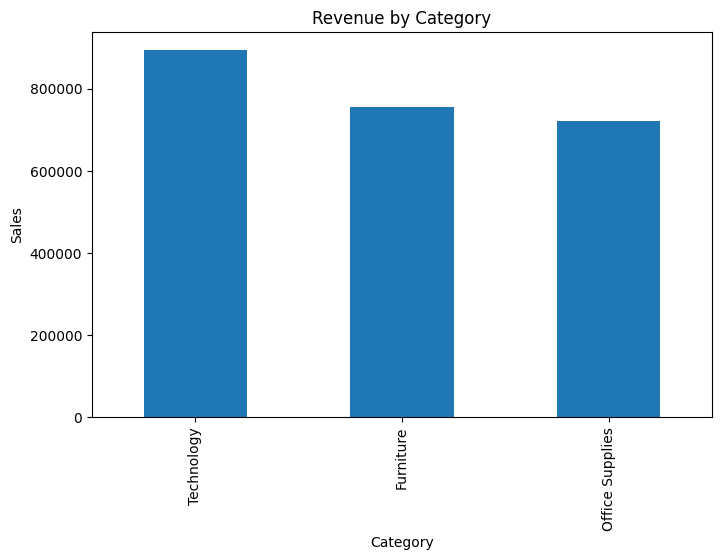

In [32]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [33]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year

In [34]:
year_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

year_sales

,Sales
Year,
2014,500363.7011
2015,484842.2060
2016,629041.9270
2017,754494.5742


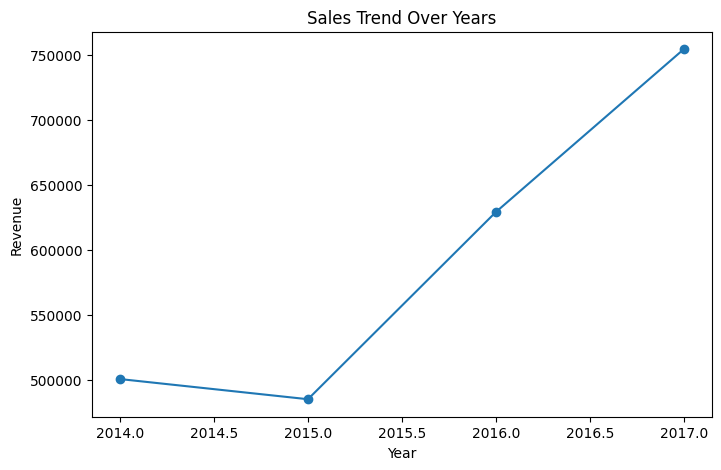

In [35]:
plt.figure(figsize=(8,5))

year_sales.plot(kind="line", marker="o")

plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.show()

In [36]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,758023.7745
East,701196.6130
Central,509883.9678
South,399638.0530


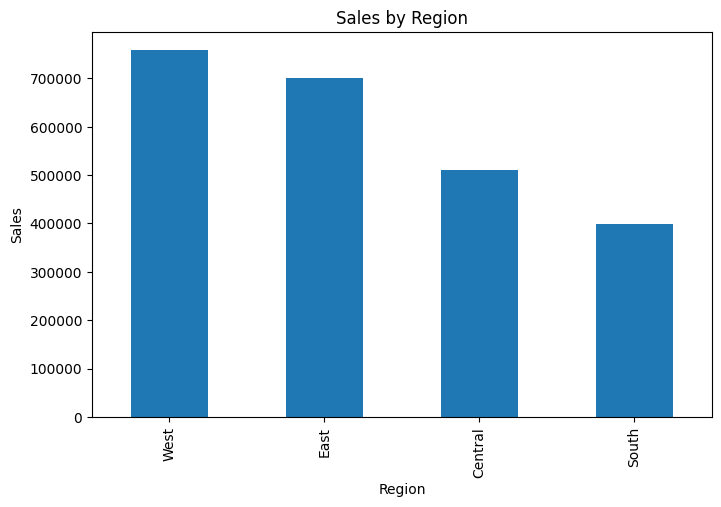

In [37]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [38]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,Sales
Customer Name,
Sean Miller,25073.818
Tamara Chand,19079.248
Greg Tran,15984.752
Raymond Buch,15117.339
Adrian Barton,14700.315
Tom Ashbrook,14595.620
Sanjit Chand,14398.094
Ken Lonsdale,14125.637
Hunter Lopez,12873.298


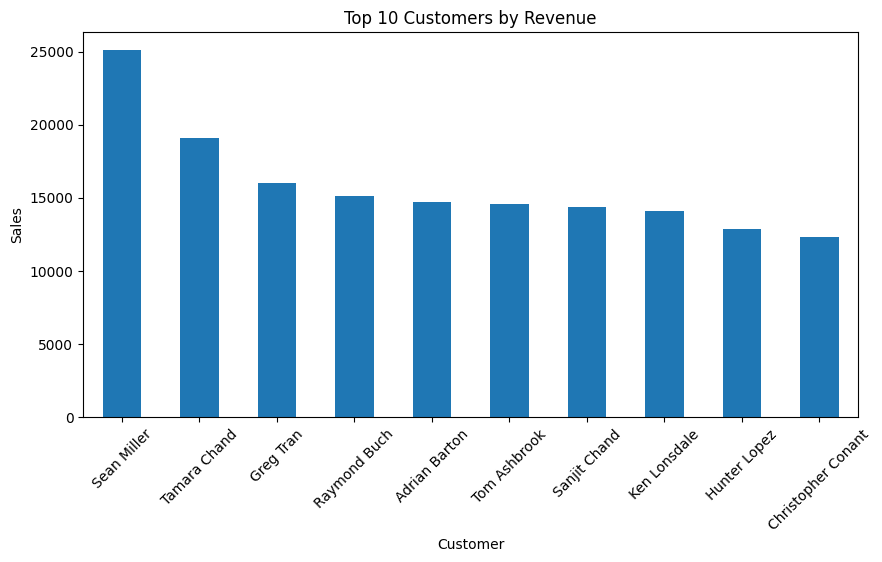

In [39]:
plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

In [40]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .mean()
)

discount_profit

,Profit
Discount,
0.00,68.515056
0.10,95.716963
0.15,27.502370
0.20,25.829624
0.30,-45.034775
0.32,-88.560656
0.40,-113.050025
0.45,-226.646464
0.50,-310.703456


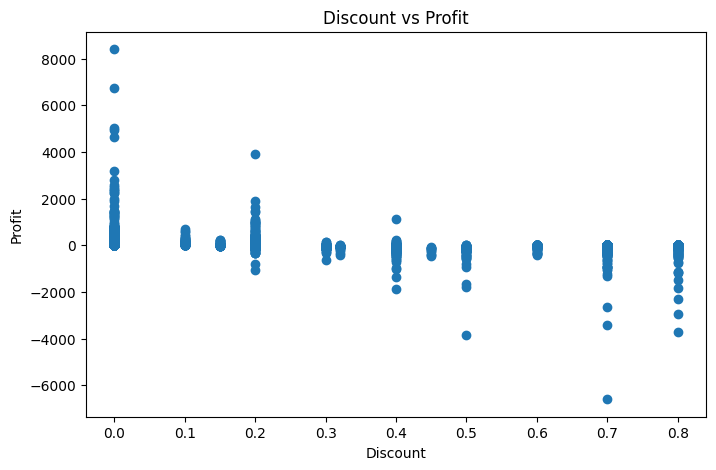

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Discount"],
    df["Profit"]
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()